## 1. Introduction
**The dataset:** World Happiness Report 2019 published by the United Nations Sustainable Development Solutions Network (SDSN). The dataset was downloaded from Kaggle: https://www.kaggle.com/datasets/unsdsn/world-happiness?select=2019.csv

**Data source:** The data comes from the Gallup World Poll and was gathered through a survey where citizens from each country were randomly selected and asked to respond to selected questions.

**What is a row?**
Each row is one country. There is a total of 156 countries in the dataset.

**What the numeric columns mean:** The columns: GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices, Generosity, and Perceptions of corruption are not the actual raw values. They represent each factor's contribution to the happiness score in a regression model. Eg, GDP is log(GDP/capita) adjusted for purchasing power parity (PPP).

**Key limitation:** This dataset shows correlations, not causation. The focus on a wealthier country being happier does not prove that wealth causes happiness especially with no consideration to different cultural view of "best life". 

In [75]:
#pip install seaborn

In [76]:
# Get required Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Dataset loading and Mechanical inspection

In [77]:
# Import/Read and inspect dataset
df = pd.read_csv("data/data-2019.csv")
print(f"Shape: {df.shape}")   # (156, 9)
print(f"Information: {df.info()}")    # data type and structure
print(f"Estimates:\n {df.describe()}")  # statistical overview

Shape: (156, 9)
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    str    
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 11.1 KB
Information: None
Estimates:
        Overall rank       Score  GDP per capita  Social support  \
count    156.000000  156.000000      156.000000      156.000000   
mean      78.500000

The ´.describe()´ output reveals several columns with a minimum value of 0.000. Looking at the Healthy life expectancy column, a 0 years would mean that people are born and immediately die. That does not seem to be correct. I guess the 0 most likely represents missing data and not actual measurements.

In [78]:
# Change column name
df = df.rename(columns={'Country or region': 'Country'})
df.head(13)
# pd.set_option('display.max_row', None)  # Removes row limit
# df.head(len(df))  # Show all data

,Overall rank,Country,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


In [79]:
# Investigate columns with 0 values of interest

columns_of_interest = ["Healthy life expectancy", "GDP per capita", "Social support"]
for col in columns_of_interest:
  zero_countries = df[df[col] == 0.000000]["Country"].tolist()
  print(f"Countries with {col} = 0: {zero_countries}")

Countries with Healthy life expectancy = 0: ['Swaziland']
Countries with GDP per capita = 0: ['Somalia']
Countries with Social support = 0: ['Central African Republic']


In [80]:
# Check and show columns with missing values
missing_values = df.isnull().sum()
print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
Series([], dtype: int64)


The `.isnull()`show no missing value. However, the 0s found above (with `.Describe()`) in Swaziland, Somalia, and Central African Republic rows could have been used to mask missing values, thereby rendering the 0s become undetectable.

## 3. Data cleaning

In [81]:
# Rename all columns name to snake_case style
# This is to minimize error especially when accessing with dot notation and make code cleaner
df = df.rename(columns={
  "Overall rank": "rank",
  "Country": "country",
  "Score": "score",
  "GDP per capita": "gdp",
  "Social support": "social_support",
  "Healthy life expectancy": "life_expectancy",
  "Freedom to make life choices": "freedom",
  "Generosity": "generosity",
  "Perceptions of corruption": "corruption",
})
print(df.columns.tolist())

['rank', 'country', 'score', 'gdp', 'social_support', 'life_expectancy', 'freedom', 'generosity', 'corruption']


In [82]:
# Add a region column based on previous years data grouping
# This is to let me practice ".groupby()" function and compare Happiness score with a region
region_map = {
    # Nordics
    "Finland": "Nordics", 
    "Denmark": "Nordics", 
    "Norway": "Nordics",
    "Iceland": "Nordics", 
    "Sweden": "Nordics",

    # Western Europe
    "Netherlands": "Western Europe", 
    "Switzerland": "Western Europe",
    "Austria": "Western Europe", 
    "Luxembourg": "Western Europe",
    "United Kingdom": "Western Europe", 
    "Ireland": "Western Europe",
    "Germany": "Western Europe", 
    "Belgium": "Western Europe",
    "France": "Western Europe", 
    "Spain": "Western Europe",
    "Portugal": "Western Europe", 
    "Italy": "Western Europe",
    "Malta": "Western Europe", 
    "Cyprus": "Western Europe",
    "Northern Cyprus": "Western Europe", 
    "Greece": "Western Europe",

    # Eastern Europe & Central Asia
    "Czech Republic": "Eastern Europe & Central Asia",
    "Slovakia": "Eastern Europe & Central Asia",
    "Poland": "Eastern Europe & Central Asia",
    "Lithuania": "Eastern Europe & Central Asia",
    "Latvia": "Eastern Europe & Central Asia",
    "Estonia": "Eastern Europe & Central Asia",
    "Romania": "Eastern Europe & Central Asia",
    "Slovenia": "Eastern Europe & Central Asia",
    "Hungary": "Eastern Europe & Central Asia",
    "Croatia": "Eastern Europe & Central Asia",
    "Serbia": "Eastern Europe & Central Asia",
    "Moldova": "Eastern Europe & Central Asia",
    "Montenegro": "Eastern Europe & Central Asia",
    "Bosnia and Herzegovina": "Eastern Europe & Central Asia",
    "Bulgaria": "Eastern Europe & Central Asia",
    "North Macedonia": "Eastern Europe & Central Asia",
    "Kosovo": "Eastern Europe & Central Asia",
    "Belarus": "Eastern Europe & Central Asia",
    "Ukraine": "Eastern Europe & Central Asia",
    "Russia": "Eastern Europe & Central Asia",
    "Kazakhstan": "Eastern Europe & Central Asia",
    "Kyrgyzstan": "Eastern Europe & Central Asia",
    "Tajikistan": "Eastern Europe & Central Asia",
    "Turkmenistan": "Eastern Europe & Central Asia",
    "Uzbekistan": "Eastern Europe & Central Asia",
    "Azerbaijan": "Eastern Europe & Central Asia",
    "Armenia": "Eastern Europe & Central Asia",
    "Georgia": "Eastern Europe & Central Asia",

    # Middle East & North Africa
    "United Arab Emirates": "Middle East & North Africa",
    "Saudi Arabia": "Middle East & North Africa",
    "Qatar": "Middle East & North Africa",
    "Bahrain": "Middle East & North Africa",
    "Israel": "Middle East & North Africa",
    "Kuwait": "Middle East & North Africa",
    "Libya": "Middle East & North Africa",
    "Lebanon": "Middle East & North Africa",
    "Algeria": "Middle East & North Africa",
    "Morocco": "Middle East & North Africa",
    "Jordan": "Middle East & North Africa",
    "Palestinian Territories": "Middle East & North Africa",
    "Iran": "Middle East & North Africa",
    "Tunisia": "Middle East & North Africa",
    "Iraq": "Middle East & North Africa",
    "Egypt": "Middle East & North Africa",
    "Syria": "Middle East & North Africa",
    "Yemen": "Middle East & North Africa",
    "Mauritania": "Middle East & North Africa",

    # Sub-Saharan Africa
    "Nigeria": "Sub-Saharan Africa", 
    "Ghana": "Sub-Saharan Africa",
    "Ivory Coast": "Sub-Saharan Africa", 
    "Benin": "Sub-Saharan Africa",
    "Congo (Brazzaville)": "Sub-Saharan Africa",
    "Congo (Kinshasa)": "Sub-Saharan Africa",
    "Gabon": "Sub-Saharan Africa", 
    "South Africa": "Sub-Saharan Africa",
    "Namibia": "Sub-Saharan Africa", 
    "Niger": "Sub-Saharan Africa",
    "Burkina Faso": "Sub-Saharan Africa", 
    "Guinea": "Sub-Saharan Africa",
    "Gambia": "Sub-Saharan Africa", 
    "Kenya": "Sub-Saharan Africa",
    "Mozambique": "Sub-Saharan Africa", 
    "Senegal": "Sub-Saharan Africa",
    "Somalia": "Sub-Saharan Africa", 
    "Cameroon": "Sub-Saharan Africa",
    "Mali": "Sub-Saharan Africa", 
    "Sierra Leone": "Sub-Saharan Africa",
    "Chad": "Sub-Saharan Africa", 
    "Ethiopia": "Sub-Saharan Africa",
    "Swaziland": "Sub-Saharan Africa", 
    "Uganda": "Sub-Saharan Africa",
    "Zambia": "Sub-Saharan Africa", 
    "Togo": "Sub-Saharan Africa",
    "Liberia": "Sub-Saharan Africa", 
    "Comoros": "Sub-Saharan Africa",
    "Madagascar": "Sub-Saharan Africa", 
    "Lesotho": "Sub-Saharan Africa",
    "Burundi": "Sub-Saharan Africa", 
    "Zimbabwe": "Sub-Saharan Africa",
    "Rwanda": "Sub-Saharan Africa", 
    "Tanzania": "Sub-Saharan Africa",
    "Malawi": "Sub-Saharan Africa", 
    "South Sudan": "Sub-Saharan Africa",
    "Central African Republic": "Sub-Saharan Africa",

    # Latin America & Caribbean
    "Mexico": "Latin America & Caribbean",
    "Guatemala": "Latin America & Caribbean",
    "El Salvador": "Latin America & Caribbean",
    "Nicaragua": "Latin America & Caribbean",
    "Brazil": "Latin America & Caribbean",
    "Colombia": "Latin America & Caribbean",
    "Ecuador": "Latin America & Caribbean",
    "Bolivia": "Latin America & Caribbean",
    "Paraguay": "Latin America & Caribbean",
    "Peru": "Latin America & Caribbean",
    "Argentina": "Latin America & Caribbean",
    "Uruguay": "Latin America & Caribbean",
    "Chile": "Latin America & Caribbean",
    "Panama": "Latin America & Caribbean",
    "Costa Rica": "Latin America & Caribbean",
    "Trinidad & Tobago": "Latin America & Caribbean",
    "Jamaica": "Latin America & Caribbean",
    "Dominican Republic": "Latin America & Caribbean",
    "Haiti": "Latin America & Caribbean",
    "Honduras": "Latin America & Caribbean",
    "Venezuela": "Latin America & Caribbean",

    # North America
    "United States": "North America",
    "Canada": "North America",

    # Asia-Pacific
    "New Zealand": "Asia-Pacific", 
    "Australia": "Asia-Pacific",
    "Singapore": "Asia-Pacific", 
    "Japan": "Asia-Pacific",
    "South Korea": "Asia-Pacific", 
    "Taiwan": "Asia-Pacific",
    "Hong Kong": "Asia-Pacific", 
    "Malaysia": "Asia-Pacific",
    "Thailand": "Asia-Pacific", 
    "Indonesia": "Asia-Pacific",
    "Philippines": "Asia-Pacific", 
    "Vietnam": "Asia-Pacific",
    "China": "Asia-Pacific", 
    "Mongolia": "Asia-Pacific",
    "Bhutan": "Asia-Pacific", 
    "Cambodia": "Asia-Pacific",
    "Laos": "Asia-Pacific", 
    "Bangladesh": "Asia-Pacific",
    "Nepal": "Asia-Pacific", 
    "Pakistan": "Asia-Pacific",
    "India": "Asia-Pacific", 
    "Sri Lanka": "Asia-Pacific",
    "Myanmar": "Asia-Pacific", 
    "Afghanistan": "Asia-Pacific",
}

df["region"] = df["country"].map(region_map)

In [83]:
# Verify inserted Region column
df.head(156)

,rank,country,score,gdp,social_support,life_expectancy,freedom,generosity,corruption,region
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,Nordics
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,Nordics
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,Nordics
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,Nordics
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,Western Europe
...,...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411,Sub-Saharan Africa
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147,Sub-Saharan Africa
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025,Asia-Pacific
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035,Sub-Saharan Africa


In [84]:
# Verify there is no country without a region
unmapped = df[df["region"].isna()]["country"].tolist()
print(f"Countries without a region mapping: {unmapped}")

Countries without a region mapping: ['Mauritius', 'Turkey', 'Albania', 'Botswana']


The `.isna()` detected four countries without a region mapping: 'Mauritius', 'Turkey', 'Albania', 'Botswana'. Each of them contains NaN instead.

In [85]:
# Verify if any country appears more than once
# Number of total rows must be equal to number of unique countries 
# to prove that all countries appeared only once
print(f"Total rows: {len(df)}")   # expected 156
print(f"Unique countries: {df["country"].nunique()}")   # expected 156

Total rows: 156
Unique countries: 156


In [86]:
# Fill in the missing region cells
missing_regions = {
    "Mauritius": "Sub-Saharan Africa",
    "Turkey": "Middle East & North Africa",
    "Albania": "Eastern Europe & Central Asia",
    "Botswana": "Sub-Saharan Africa",
}

df["region"] = df["region"].fillna(df["country"].map(missing_regions))

In [87]:
# Verify again that all country has a region
# An empty list [] shows that all the region cells has a real value
unmapped = df[df["region"].isna()]["country"].tolist()
print(f"Countries without a region mapping: {unmapped}")

Countries without a region mapping: []


## 4. Exploration through visualization

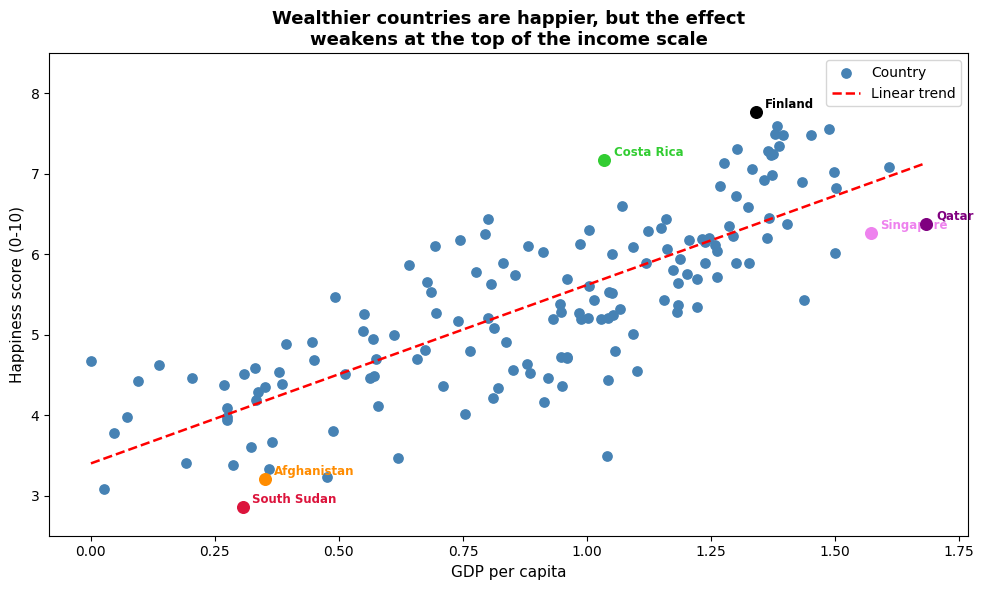

In [ ]:
#  Visualization 1: Happiness score vs GDP per capita
# Question: Does money buy happiness? And if yes or no, does it reflect across all the countries

fig, ax = plt.subplots(figsize=(10, 6))

# Represent countries in blue dots
ax.scatter(df["gdp"], df["score"],
           color="steelblue", alpha=1.0, s=45, label="Country")

coeffs = np.polyfit(df["gdp"], df["score"], deg=1)
x_line = np.linspace(df["gdp"].min(), df["gdp"].max(), 2)
y_line = np.polyval(coeffs, x_line)
ax.plot(x_line, y_line, color="red", linewidth=1.8,
        linestyle="--", label="Linear trend")

# Annotate some countries
highlight = {
    "Finland":     "black",
    "South Sudan": "crimson",
    "Afghanistan": "darkorange",
    "Costa Rica":  "limegreen",
    "Singapore": "violet",
    "Qatar": "purple"
}
for country, color in highlight.items():
    row = df[df["country"] == country].iloc[0]
    ax.scatter(row["gdp"], row["score"], color=color, s=70, zorder=5)
    ax.annotate(country,
                xy=(row["gdp"], row["score"]),
                xytext=(7, 3), textcoords="offset points",
                fontsize=8.5, color=color, fontweight="bold")

# Give figure title and label axes
ax.set_title("Wealthier countries are happier, but the effect\n"
             "weakens at the top of the income scale",
             fontsize=13, fontweight="bold")
ax.set_xlabel("GDP per capita", fontsize=11)
ax.set_ylabel("Happiness score (0-10)", fontsize=11)
ax.legend()
ax.set_ylim(2.5, 8.5) # Truncate y-axis starting from 2.5

plt.tight_layout()
plt.show()

I choose a scatter plot as most appropriate to represent the relationship between two continuous variables (Happiness score and GDP per capita) across 156 individual observations. Other charts like a bar chart will lead to loss of some countries position due to over crowding, also a line chart would imply a time order or sequential or progression pattern, that does not exist.
The scatter plot shows a positive correlation between GDP per capita and happiness score, althouugh the trend flattens at highest GDP level (Eg; Singapore and Qatar) where countries with highest GDP are not necessarily the most happiest country.

The y-axis was truncated because the lowest Happiness score is 2.8, truncation makes the plotted point to spread out more thereby enhancing visual readability. Thus, y-axis started at 2.5.

### Visualization 2: 
Comparing Top 10 vs Bottom 5 countries Happiness score
Question? How large is the gap between the happiest and unhappiest countries in 2019?
For this, I tested two bar chart orientations - vertical bar chart and horizontal bar chart

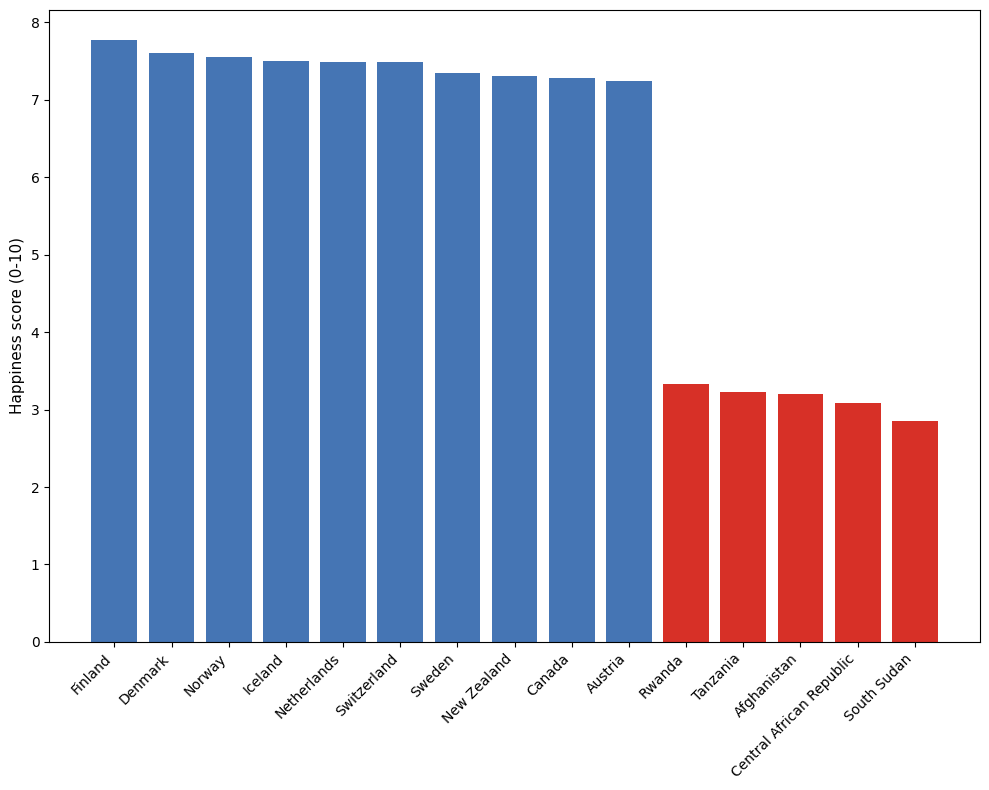

In [ ]:
# Visualization 2A: Vertical bar chart
fig, ax = plt.subplots(figsize=(10, 8))
top10_test = df.nlargest(10, "score")
bottom5_test = df.nsmallest(5, "score")
combined_test = pd.concat([top10_test, bottom5_test]).sort_values("score", ascending=False)
colors = ["#d73027" if s < 4.5 else "#4575b4" for s in combined_test["score"]]
ax.bar(combined_test["country"], combined_test["score"], color=colors)
plt.xticks(rotation=45, ha="right")
ax.set_ylabel("Happiness score (0-10)", fontsize=11)
plt.tight_layout()
plt.show()

**Reflection:** Vertical bar chart did not look visually good, long x-axis. I do no think it the best.

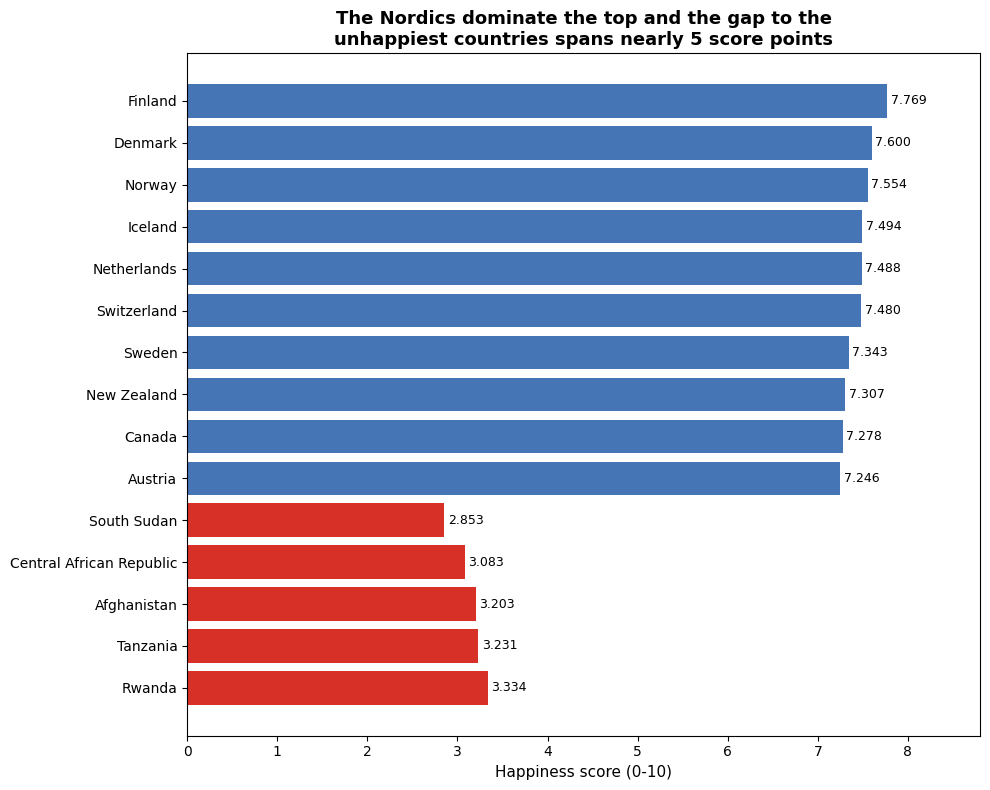

In [ ]:
# Visualization 2B: Horizontal bar chart
top10   = df.nlargest(10, "score").sort_values("score")
bottom5 = df.nsmallest(5, "score").sort_values("score", ascending=False)
selected = pd.concat([bottom5, top10])

colors = ["#d73027" if s < 4.5 else "#4575b4" for s in selected["score"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(selected["country"], selected["score"], color=colors)

# Annotate score bar
for bar, val in zip(bars, selected["score"]):
    ax.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_title("The Nordics dominate the top and the gap to the\n"
             "unhappiest countries spans nearly 5 score points",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Happiness score (0-10)", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 8.8)  # x-axis ranges from 0 - 8.8

plt.tight_layout()
plt.show()

The gap between the happiest country, Finland (7.769), and the unhappiest country, South sudan (2.853), is 4.916 score point. This is a strong different that this bar chart shows.

In [91]:
# Estimate correlation with happiness score
numeric_cols = ["gdp", "social_support", "life_expectancy",
                "freedom", "generosity", "corruption"]
correlations_with_score = df[numeric_cols].corrwith(df["score"]).sort_values(ascending=False)
print(f"Correlation with happiness score:\n {correlations_with_score.round(3)}")

Correlation with happiness score:
 gdp                0.794
life_expectancy    0.780
social_support     0.777
freedom            0.567
corruption         0.386
generosity         0.076
dtype: float64


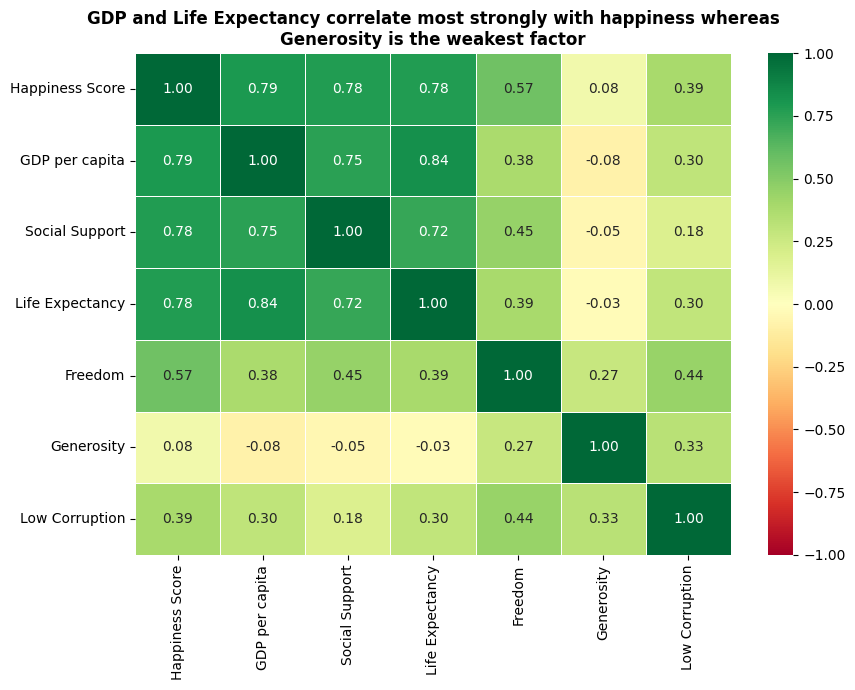

In [ ]:
# Visualization 3A: Correlation between Happiness score and all other variables
# Correlation matrix heatmap plot

cols_for_heatmap = ["score", "gdp", "social_support", "life_expectancy",
                    "freedom", "generosity", "corruption"]
corr_matrix = df[cols_for_heatmap].corr()

# Rename columns for readable axis labels
readable_names = {
    "score":          "Happiness Score",
    "gdp":            "GDP per capita",
    "social_support": "Social Support",
    "life_expectancy":"Life Expectancy",
    "freedom":        "Freedom",
    "generosity":     "Generosity",
    "corruption":     "Low Corruption",
}
corr_matrix = corr_matrix.rename(index=readable_names, columns=readable_names)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title("GDP and Life Expectancy correlate most strongly with happiness whereas\n"
             "Generosity is the weakest factor",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

Happiness correlates strongly with GDP per capita (r = 0.79) and Social support (r = 0.78). On the other hand, Happiness has a very weak correlation with generosity (r = 0.08).

Another interesting observation is that Happiness is positively correlated with Low corruption (r = 0.39).

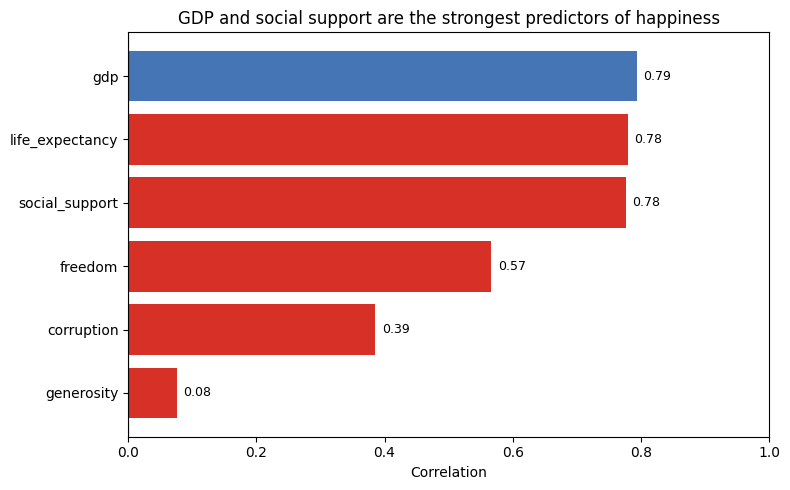

In [ ]:
# # Visualization 3B: Correlation between Happiness score and GDP per capita
# Correlation of each variable with happiness score - bar chart
corr_with_score = df[["gdp", "social_support", "life_expectancy",
                       "freedom", "generosity", "corruption"]].corrwith(df["score"])

corr_sorted = corr_with_score.sort_values()

bars = ax.barh(corr_sorted.index, corr_sorted.values, color="#4575b4")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colors)

# Annotate each bar with its r-value
for bar, val in zip(bars, corr_sorted.values):
    ax.text(val + 0.01 if val > 0 else val - 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}",
            va="center",
            ha="left" if val > 0 else "right",
            fontsize=9)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(0, 1.0)
ax.set_xlabel("Correlation")
ax.set_title("GDP and social support are the strongest predictors of happiness")
plt.tight_layout()
plt.show()

**Correlation bar chart** To show clearly which variable correlates strongest with Happiness score.

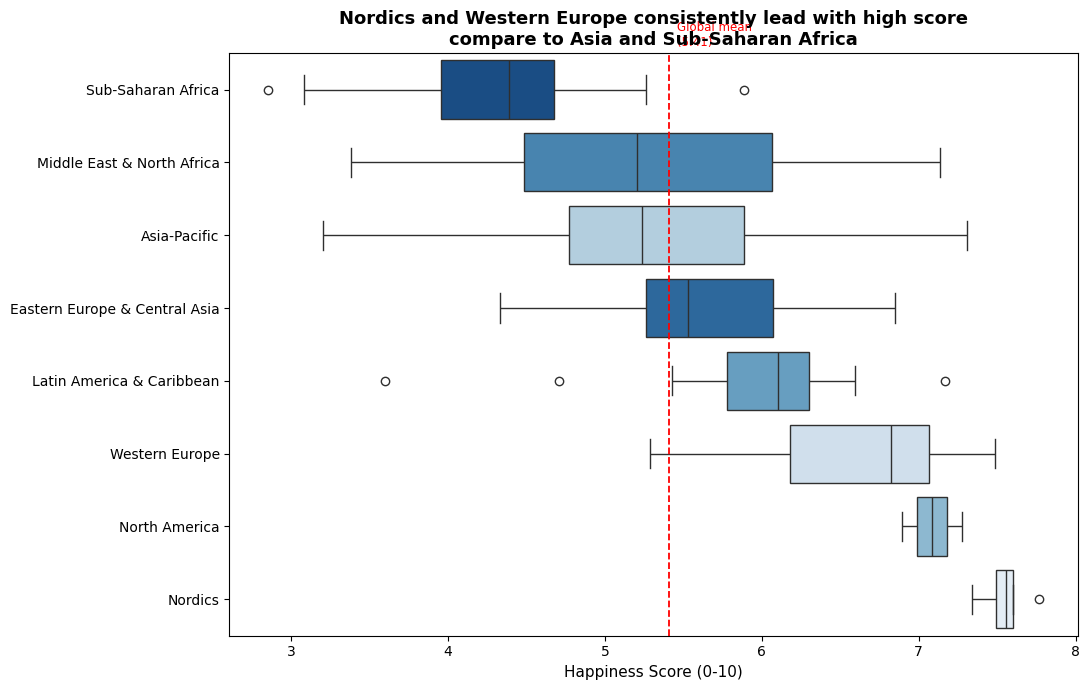

In [ ]:
# Visualization 4: Boxplot of Happiness distribution per region
# Question: Does a regional belonging a stronger predictor of happiness than any single economic factor?
#  Sort regions by median score
region_order = (
    df.groupby("region")["score"]
      .median()
      .sort_values(ascending=True)
      .index.tolist()
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.boxplot(
    data=df,
    x="score",
    y="region",
    order=region_order,
    hue="region",
    palette="Blues",
    ax=ax
)

# Reference line at global mean
mean_score = df["score"].mean()
ax.axvline(mean_score, color="red", linestyle="--", linewidth=1.3)
ax.text(mean_score + 0.05, -0.6,
        f"Global mean\n({mean_score:.2f})", color="red", fontsize=8.5)

ax.set_title("Nordics and Western Europe consistently lead with high score\n"
             "compare to Asia and Sub-Saharan Africa",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Happiness Score (0-10)", fontsize=11)
ax.set_ylabel("", fontsize=11)

plt.tight_layout()
plt.show()

The Nordics as well as North American has highest Happiness score and smallest variance, which reflects consistent happiness across the regions. On the other hand, Middle East and Sub-Saharan Africa have a lowest happiness score and wide variance across the region. 

## Conclusion

### Patterns discovered
The analysis reveal that Northern Europe (Nordics) consistently occupies the top of the Happiness score ranking while Sub-Saharan Africa and Middle East are in the bottom cluster. This pattern consistent across almost every variable: GDP per capita, social support, life expectancy, and freedom to make life choices. The strongest predictor of happiness was GDP per capita (r ≈ 0.79), but social support and healthy life expectancy were also strong. This suggests that wealth alone does not explain happiness, rather a combination of other factors. Generosity stood out as an anomaly with no linear relationship with happiness (r ≈ 0.08), suggesting act of kindness to strangers does not contribute to national happiness score.

### Unanswered questions
The data could not explain why some countries out perform their economic level. Costa Rica and Mexico, for example, score higher happiness level than their GDP per capita would predict. on the other hand, some countries with high GDP per capita (E.g., Singapore and Qatar) have lower happiness score than expected. We also could not determine the exact pattern whether it is wealth that cause happiness, or is happier societies that are economically successful? The dataset offers correlation only. The data also did not show whether those measured variables has changed over the previous years or they have stayed the same, but one will need to analyze more data for this.

### What the data cannot show
The happiness score is a national average of self-reported wellbeing, this method did not show a number of realities:
- The inequality that exist within a country, that is, inequality in wealth distribution.
- Difference in willingness or societal acceptance to talk about dissatisfaction that exist across different countries.
- The six variables chosen by the report seems to reflect western view of what produces wellbeing. Factors that might more important to third world countries like spiritual life, community belonging, etc was not included in the study.